# ML - Aprendizaje No Supervisado, Semi-supervisado y Activo

Este cuadernillo tiene como objetivo estudiar y aplicar técnicas de **Aprendizaje No Supervisado**, **Aprendizaje Semi-supervisado** y **Aprendizaje Activo** utilizando tanto datos sintéticos como un conjunto de datos real de imágenes de componentes electrónicos.

El trabajo se divide en dos partes principales:

1. **Parte 1 (Punto 1)**: Modificación del generador de datasets aleatorios para generar centroides bien separados (de 1 a 20 clusters) en 2D, permitiendo la verificación visual. Demostración práctica del algoritmo **KMeans**, el **Método del Codo (Elbow Method)** y el **Coeficiente de Silueta (Silhouette Score)** con diagramas de silueta por cluster.
2. **Parte 2 (Punto 2)**: Aplicación de **Aprendizaje Semi-supervisado** y **Aprendizaje Activo** sobre un dataset real de **imágenes de componentes electrónicos** ubicado en la carpeta `images`. Pasaremos por el preprocesamiento de imágenes (redimensionamiento, conversión a escala de grises, normalización y aplanado) y la evaluación cuantitativa y cualitativa de los modelos.


## Parte 1: Generación y Análisis de Clusters Sintéticos (Punto 1)

En esta sección, modificaremos la generación de conjuntos de datos aleatorios. El objetivo es:
- Generar un número aleatorio de centroides $k$ entre 1 y 20.
- Garantizar que los centroides tengan una distancia significativa entre sí para permitir una verificación visual nítida.
- Aplicar KMeans, graficar las fronteras de decisión y evaluar el número óptimo de clusters usando el método del codo y las siluetas.


In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

def generate_separated_centroids(k, min_dist=4.0, x_range=(-15, 15), y_range=(-15, 15), max_attempts=500):
    """
    Genera k centroides en 2D asegurando que la distancia euclidiana entre cualquiera
    de ellos sea al menos `min_dist`. Utiliza muestreo por rechazo.
    """
    centroids = []
    for _ in range(k):
        found = False
        attempts = 0
        while not found and attempts < max_attempts:
            candidate = np.array([
                np.random.uniform(x_range[0], x_range[1]),
                np.random.uniform(y_range[0], y_range[1])
            ])
            # Verificar distancia con centroides existentes
            if len(centroids) == 0:
                centroids.append(candidate)
                found = True
            else:
                dists = [np.linalg.norm(candidate - c) for c in centroids]
                if min(dists) >= min_dist:
                    centroids.append(candidate)
                    found = True
            attempts += 1
        # Si fallan los intentos por exceso de densidad, reducir min_dist temporalmente
        if not found:
            # Caso de salvaguarda
            centroids.append(candidate)
            
    return np.array(centroids)

# Elegir k aleatorio entre 1 y 20 para la demostración
np.random.seed(42)  # Para reproducibilidad en la generación inicial
k_true = np.random.randint(1, 21)
print(f"Número real de clusters seleccionado (k_true): {k_true}")

# Generar centroides bien separados (mínimo 4.5 unidades de distancia)
blob_centers = generate_separated_centroids(k=k_true, min_dist=4.5)

# Generar el dataset usando make_blobs con una desviación estándar pequeña (0.5)
# Esto asegura que los clusters no se solapen excesivamente y la verificación visual sea clara
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=0.5, random_state=42)

print(f"Dataset sintético generado con {X.shape[0]} muestras y {X.shape[1]} características.")


Número real de clusters seleccionado (k_true): 7
Dataset sintético generado con 2000 muestras y 2 características.


C:\Users\Natalia\AppData\Local\Temp\ipykernel_1752\943131007.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, s=3, cmap='viridis', alpha=0.7)


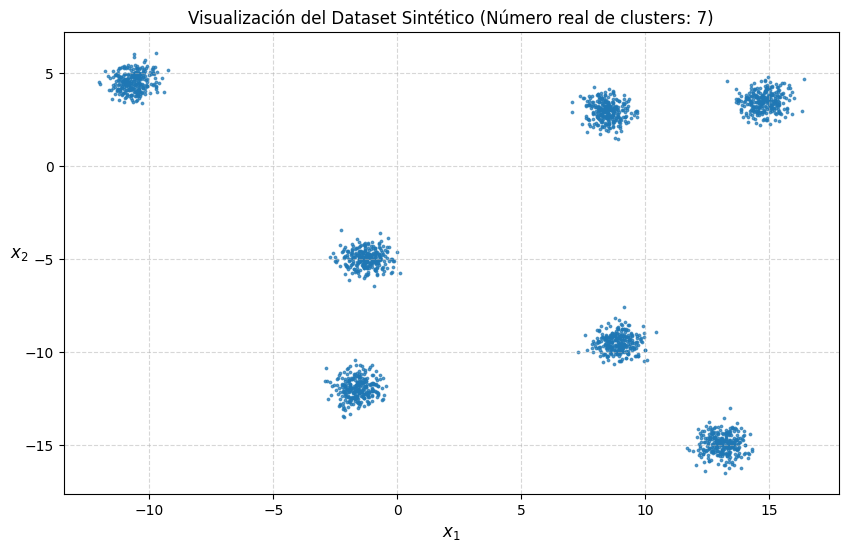

In [2]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=3, cmap='viridis', alpha=0.7)
    plt.xlabel("$x_1$", fontsize=12)
    plt.ylabel("$x_2$", fontsize=12, rotation=0)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.figure(figsize=(10, 6))
plot_clusters(X)
plt.title(f"Visualización del Dataset Sintético (Número real de clusters: {k_true})")
plt.show()


### Aplicación de K-Means y Fronteras de Decisión

Entrenaremos el modelo K-Means utilizando el número real de clusters $k_{\text{true}}$ y visualizaremos las fronteras de decisión (teselación de Voronoi) resultantes del agrupamiento.


C:\Users\Natalia\AppData\Local\Temp\ipykernel_1752\943131007.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, s=3, cmap='viridis', alpha=0.7)


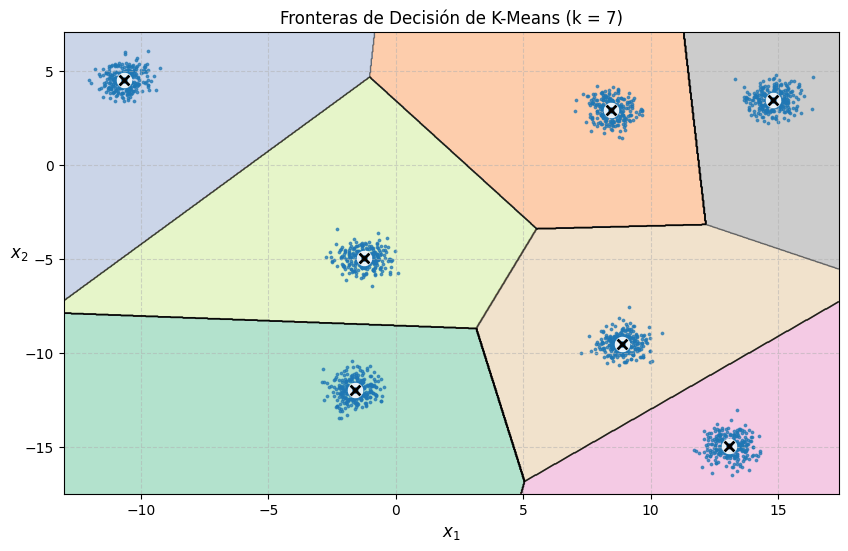

In [3]:
from sklearn.cluster import KMeans

# Entrenar K-Means con el k_true
kmeans = KMeans(n_clusters=k_true, init="k-means++", n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

def plot_centroids(centroids, circle_color='w', cross_color='k'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True):
    mins = X.min(axis=0) - 1.0
    maxs = X.max(axis=0) + 1.0
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k', alpha=0.5)
    plot_clusters(X, y=None)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

plt.figure(figsize=(10, 6))
plot_decision_boundaries(kmeans, X)
plt.title(f"Fronteras de Decisión de K-Means (k = {k_true})")
plt.show()


### Método del Codo (Elbow Method)

El método del codo nos permite buscar el número óptimo de clusters analizando la **inercia** (la suma de las distancias al cuadrado de las muestras a su centroide más cercano). Al graficar la inercia en función de $k$, buscamos el punto de inflexión o "codo", a partir del cual el descenso de la inercia se vuelve lineal y mucho más lento.


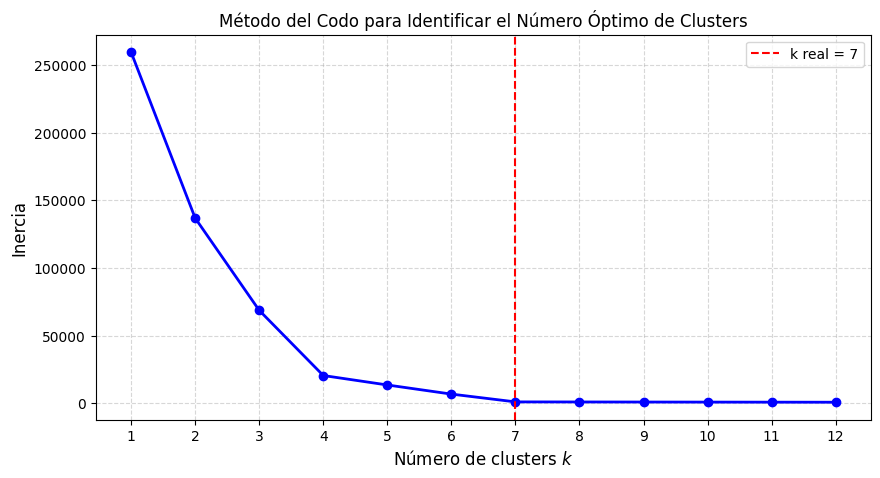

In [4]:
# Calculamos la inercia para valores de k de 1 a 20 o k_true + 5
max_k = min(20, k_true + 5) if k_true < 18 else 20
k_range = range(1, max_k + 1)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, "bo-", linewidth=2)
plt.xlabel("Número de clusters $k$", fontsize=12)
plt.ylabel("Inercia", fontsize=12)
plt.title("Método del Codo para Identificar el Número Óptimo de Clusters")
plt.axvline(x=k_true, color='r', linestyle='--', label=f'k real = {k_true}')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


### Coeficiente de Silueta (Silhouette Score)

El coeficiente de silueta mide qué tan similar es una muestra a su propio cluster comparado con otros clusters. Varía entre -1 y +1. Un coeficiente alto indica que las muestras están bien emparejadas con sus clusters y bien separadas de los vecinos.
A continuación, graficaremos el silhouette score medio en función de $k$.


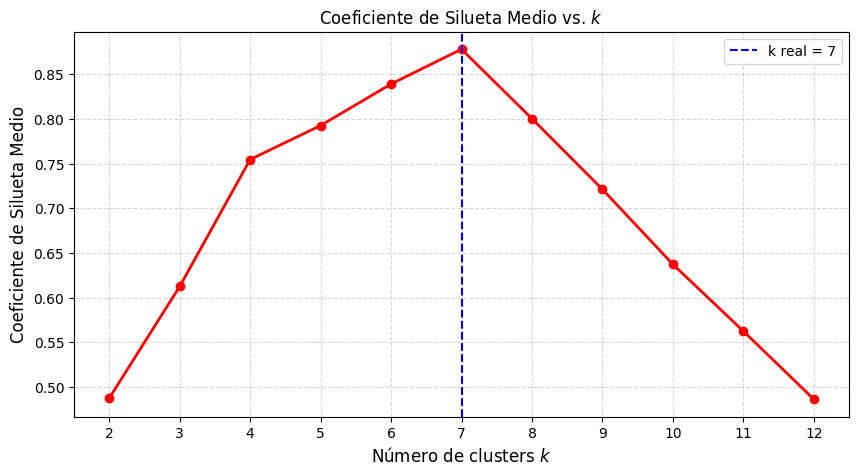

In [5]:
from sklearn.metrics import silhouette_score

# Calculamos el silhouette score para k entre 2 y max_k (el score requiere al menos 2 clusters)
silhouette_k_range = range(2, max_k + 1)
silhouette_scores = []

for k in silhouette_k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X)
    score = silhouette_score(X, km.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(silhouette_k_range, silhouette_scores, "ro-", linewidth=2)
plt.xlabel("Número de clusters $k$", fontsize=12)
plt.ylabel("Coeficiente de Silueta Medio", fontsize=12)
plt.title("Coeficiente de Silueta Medio vs. $k$")
plt.axvline(x=k_true, color='blue', linestyle='--', label=f'k real = {k_true}')
plt.xticks(silhouette_k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


### Diagramas de Silueta por Cluster

Para analizar más a fondo la calidad del agrupamiento, visualizaremos los **diagramas de silueta**. Estos gráficos muestran el coeficiente de silueta de cada muestra ordenado por su cluster, lo cual nos permite ver si algunos clusters son mucho más densos o si hay muestras mal clasificadas (con valores negativos).
Compararemos el diagrama para $k_{true} - 1$, $k_{true}$ y $k_{true} + 1$ (si los valores son válidos).


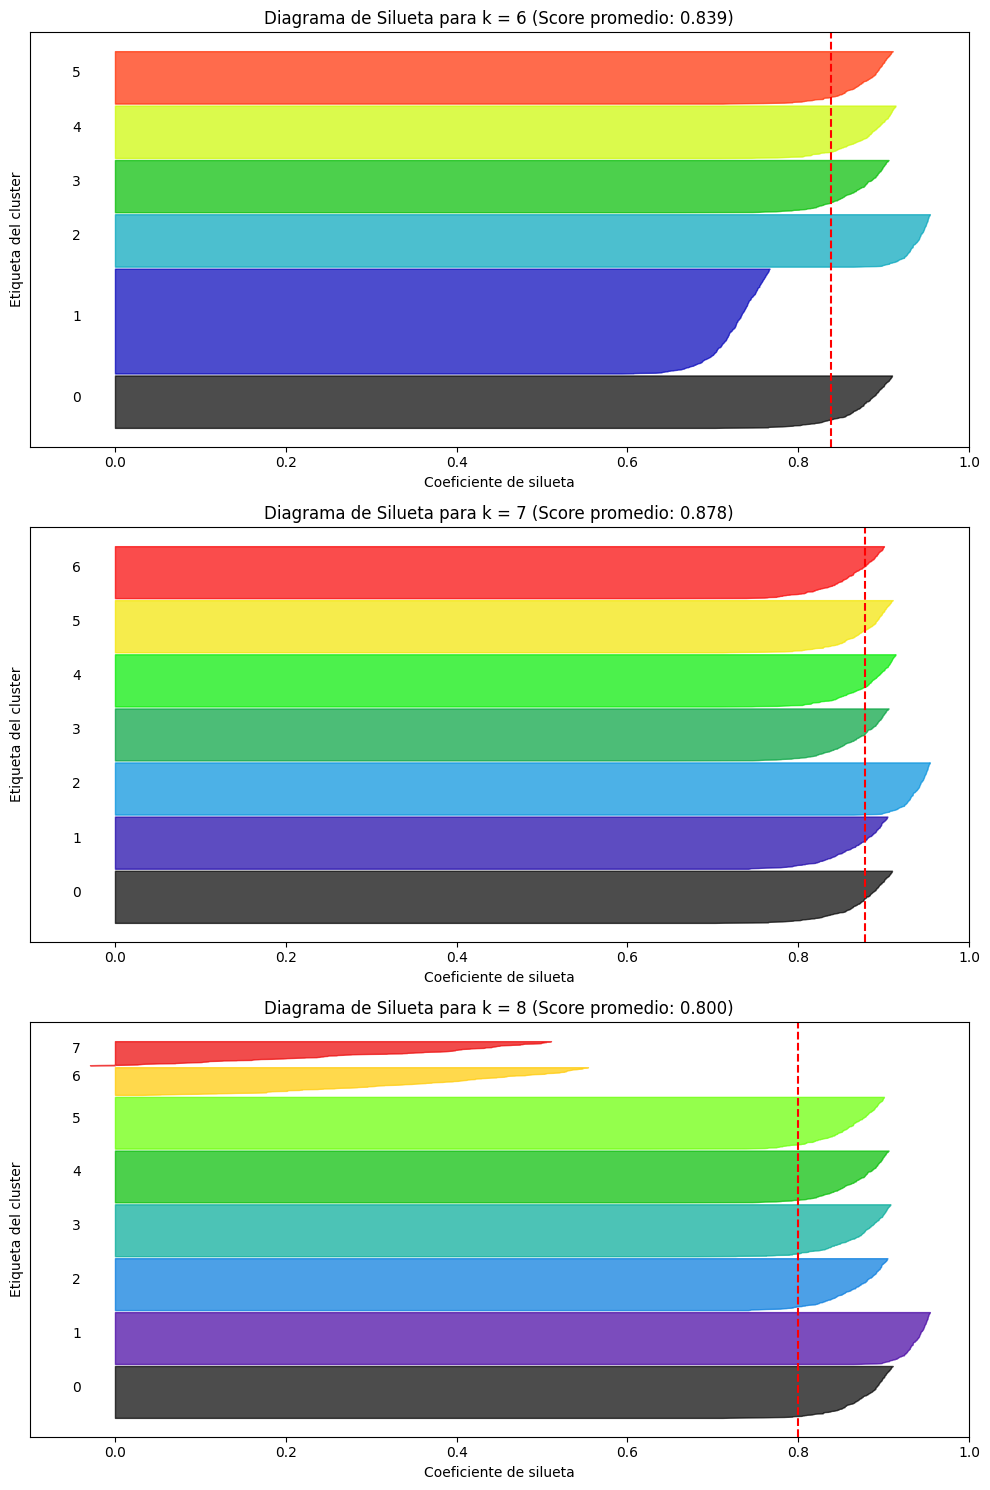

In [6]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Seleccionamos tres valores de k para comparar
k_candidates = []
if k_true > 2:
    k_candidates.append(k_true - 1)
k_candidates.append(k_true)
if k_true < 20:
    k_candidates.append(k_true + 1)

fig, axes = plt.subplots(len(k_candidates), 1, figsize=(10, 5 * len(k_candidates)))
if len(k_candidates) == 1:
    axes = [axes]

for i, k in enumerate(k_candidates):
    ax = axes[i]
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X)
    
    # Calcular el score medio y los scores de cada muestra
    silhouette_avg = silhouette_score(X, cluster_labels)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    
    y_lower = 10
    for j in range(k):
        # Agrupar los coeficientes de las muestras del cluster j y ordenarlos
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == j]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(j) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        # Etiquetar cada cluster en el medio del diagrama
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(j))
        y_lower = y_upper + 10
        
    ax.set_title(f"Diagrama de Silueta para k = {k} (Score promedio: {silhouette_avg:.3f})")
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_ylabel("Etiqueta del cluster")
    
    # Dibujar línea vertical para el coeficiente medio
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])  # Limpiar ticks del eje Y
    ax.set_xlim([-0.1, 1.0])

plt.tight_layout()
plt.show()


## Parte 2: Aprendizaje Semi-supervisado y Activo con Componentes Electrónicos (Punto 2)

En este bloque aplicaremos técnicas avanzadas sobre el conjunto de datos de **imágenes de componentes electrónicos** ubicado en la carpeta `images`.
1. **Línea de base**: Entrenaremos un clasificador con un subconjunto aleatorio de 50 imágenes etiquetadas.
2. **Aprendizaje Semi-supervisado**:
   - Agruparemos las imágenes en 50 clusters.
   - Identificaremos la imagen más representativa de cada cluster (centroide).
   - "Etiquetaremos" estas 50 imágenes clave y evaluaremos el clasificador.
   - Propagaremos las etiquetas de los representantes a todo el cluster y reentrenaremos.
3. **Aprendizaje Activo**:
   - Encontraremos las 50 imágenes del conjunto de entrenamiento donde el clasificador tiene la menor confianza.
   - Solicitaremos sus etiquetas (oráculo) y actualizaremos el conjunto de entrenamiento para mejorar la precisión.


In [7]:
import os
from PIL import Image
import numpy as np

def load_electronic_components_dataset(base_path, target_size=(32, 32), max_images_per_class=100):
    """
    Busca subcarpetas dentro de base_path, carga las imágenes en escala de grises,
    las redimensiona a target_size, las normaliza y las aplana en vectores de características.
    Limitamos la cantidad por clase para optimizar la velocidad y el uso de memoria.
    """
    X = []
    y = []
    class_names = []
    
    # Comprobamos las rutas posibles (tanto la carpeta 'images' como una subcarpeta interna 'images')
    paths_to_try = [base_path, os.path.join(base_path, "images")]
    found_dirs = {}
    
    for p in paths_to_try:
        if not os.path.exists(p):
            continue
        for entry in os.listdir(p):
            full_path = os.path.join(p, entry)
            if os.path.isdir(full_path) and entry != "images":
                # Validamos que contenga imágenes
                files = [f for f in os.listdir(full_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if len(files) > 0:
                    found_dirs[entry] = full_path
                    
    # Ordenar clases
    sorted_classes = sorted(found_dirs.keys())
    
    print(f"Se encontraron {len(sorted_classes)} clases en el dataset.")
    
    # Cargar un subconjunto de clases (hasta 10) para asegurar la eficiencia del entrenamiento en el entorno local
    selected_classes = sorted_classes[:10]
    print(f"Clases seleccionadas para el entrenamiento: {selected_classes}")
    
    for class_idx, class_name in enumerate(selected_classes):
        class_dir = found_dirs[class_name]
        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Limitar la cantidad por clase
        files = files[:max_images_per_class]
        
        for filename in files:
            img_path = os.path.join(class_dir, filename)
            try:
                with Image.open(img_path) as img:
                    img_gray = img.convert("L")  # Escala de grises
                    img_resized = img_gray.resize(target_size)
                    img_arr = np.array(img_resized, dtype=np.float32) / 255.0  # Normalizar [0, 1]
                    X.append(img_arr.flatten())
                    y.append(class_idx)
            except Exception as e:
                continue
                
        class_names.append(class_name)
        
    return np.array(X), np.array(y), selected_classes


In [8]:
from sklearn.model_selection import train_test_split

base_images_path = "images"
X_images, y_images, classes = load_electronic_components_dataset(base_images_path, target_size=(32, 32), max_images_per_class=100)

print(f"Dimensiones de las características (X): {X_images.shape}")
print(f"Dimensiones de las etiquetas (y): {y_images.shape}")

# Dividir en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_images, y_images, test_size=0.20, random_state=42, stratify=y_images)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")


Se encontraron 36 clases en el dataset.
Clases seleccionadas para el entrenamiento: ['Bypass-capacitor', 'Electrolytic-capacitor', 'Integrated-micro-circuit', 'LED', 'PNP-transistor', 'armature', 'attenuator', 'cartridge-fuse', 'clip-lead', 'electric-relay']
Dimensiones de las características (X): (1000, 1024)
Dimensiones de las etiquetas (y): (1000,)
Entrenamiento: 800 muestras
Prueba: 200 muestras


### Escenario A: Clasificador Base con 50 Imágenes Aleatorias

Para establecer nuestra línea de base, entrenaremos una Regresión Logística utilizando un conjunto de 50 imágenes del set de entrenamiento seleccionadas de forma completamente aleatoria.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Seleccionar 50 muestras al azar del conjunto de entrenamiento
n_labeled = 50
np.random.seed(42)
shuffled_indices = np.random.permutation(len(X_train))
X_labeled_rand = X_train[shuffled_indices[:n_labeled]]
y_labeled_rand = y_train[shuffled_indices[:n_labeled]]

# Entrenar Regresión Logística
log_reg_rand = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42)
log_reg_rand.fit(X_labeled_rand, y_labeled_rand)

# Evaluar en el conjunto de prueba
y_pred_rand = log_reg_rand.predict(X_test)
acc_rand = accuracy_score(y_test, y_pred_rand)
print(f"Exactitud (Accuracy) de la Línea de Base (50 muestras aleatorias): {acc_rand:.4f} ({acc_rand*100:.2f}%)")


Exactitud (Accuracy) de la Línea de Base (50 muestras aleatorias): 0.1500 (15.00%)


### Escenario B: Aprendizaje Semi-supervisado - Etiquetado de Representantes

En lugar de etiquetar 50 muestras al azar, usaremos **K-Means** para agrupar el conjunto de entrenamiento en 50 clusters. Luego identificaremos la imagen más representativa de cada cluster (la que está más cerca del centroide de su cluster) y las etiquetaremos. Esto asegura que cubramos la diversidad estructural del dataset de forma óptima.


In [10]:
# Agrupar las muestras de entrenamiento en 50 clusters
k_clusters = 50
kmeans_images = KMeans(n_clusters=k_clusters, n_init=10, random_state=42)
X_digits_dist = kmeans_images.fit_transform(X_train)

# Encontrar los índices de las imágenes más cercanas a los centroides (mínima distancia)
representative_indices = np.argmin(X_digits_dist, axis=0)

# Extraer estas muestras representativas y sus etiquetas reales
X_representative = X_train[representative_indices]
y_representative = y_train[representative_indices]

# Entrenar una Regresión Logística usando solo los 50 representantes clave
log_reg_rep = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42)
log_reg_rep.fit(X_representative, y_representative)

# Evaluar en el conjunto de prueba
y_pred_rep = log_reg_rep.predict(X_test)
acc_rep = accuracy_score(y_test, y_pred_rep)
print(f"Exactitud (Accuracy) utilizando 50 representantes de K-Means: {acc_rep:.4f} ({acc_rep*100:.2f}%)")


Exactitud (Accuracy) utilizando 50 representantes de K-Means: 0.2000 (20.00%)


### Escenario C: Aprendizaje Semi-supervisado - Propagación de Etiquetas

Dado que los representantes son buenos descriptores de sus respectivos clusters, podemos **propagar** la etiqueta de cada representante a todas las demás imágenes que pertenecen a su mismo cluster. De esta forma, expandimos nuestro conjunto etiquetado de 50 a todo el conjunto de entrenamiento de forma automatizada.


In [11]:
# Propagar las etiquetas del representante del cluster a todos sus miembros
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k_clusters):
    # Los elementos en el cluster i reciben la etiqueta del representante de ese cluster
    y_train_propagated[kmeans_images.labels_ == i] = y_representative[i]

# Entrenar Regresión Logística con las etiquetas propagadas a todo el set de entrenamiento
log_reg_prop = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42)
log_reg_prop.fit(X_train, y_train_propagated)

# Evaluar en el conjunto de prueba
y_pred_prop = log_reg_prop.predict(X_test)
acc_prop = accuracy_score(y_test, y_pred_prop)
print(f"Exactitud (Accuracy) con Etiquetas Propagadas: {acc_prop:.4f} ({acc_prop*100:.2f}%)")


Exactitud (Accuracy) con Etiquetas Propagadas: 0.1800 (18.00%)


c:\Users\Natalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Escenario D: Aprendizaje Activo (Active Learning) basado en la Incertidumbre

En lugar de etiquetar al azar o propagar a ciegas, el **Aprendizaje Activo** selecciona de manera inteligente las muestras en las que el clasificador tiene mayor duda.
1. Utilizaremos el modelo entrenado con etiquetas propagadas para predecir las probabilidades de las clases.
2. Buscaremos las 50 imágenes en el conjunto de entrenamiento donde la probabilidad máxima asignada a cualquier clase es la más baja (máxima incertidumbre).
3. "Consultaremos al oráculo" (etiquetas reales) para estas 50 muestras dudosas.
4. Reemplazaremos las etiquetas propagadas por las reales y volveremos a entrenar.


In [12]:
# Obtener las probabilidades de predicción para el conjunto de entrenamiento
probas = log_reg_prop.predict_proba(X_train)

# La incertidumbre se mide por la probabilidad máxima asignada a la clase ganadora
max_probas = np.max(probas, axis=1)

# Ordenar por incertidumbre (las probabilidades más bajas primero)
sorted_indices = np.argsort(max_probas)

# Tomamos los 50 casos de mayor incertidumbre
n_active = 50
active_indices = sorted_indices[:n_active]

# Copiar las etiquetas propagadas
y_train_active = y_train_propagated.copy()

# El oráculo (etiquetas reales) redefine el valor correcto para estas muestras de alta incertidumbre
y_train_active[active_indices] = y_train[active_indices]

# Entrenar Regresión Logística con Aprendizaje Activo
log_reg_active = LogisticRegression(solver="lbfgs", max_iter=500, random_state=42)
log_reg_active.fit(X_train, y_train_active)

# Evaluar en el conjunto de prueba
y_pred_active = log_reg_active.predict(X_test)
acc_active = accuracy_score(y_test, y_pred_active)
print(f"Exactitud (Accuracy) con Aprendizaje Activo (50 dudas resueltas): {acc_active:.4f} ({acc_active*100:.2f}%)")


Exactitud (Accuracy) con Aprendizaje Activo (50 dudas resueltas): 0.1850 (18.50%)


c:\Users\Natalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Resumen Comparativo de Resultados

A continuación consolidamos el rendimiento obtenido en cada escenario del dataset de componentes electrónicos. La celda de código a continuación imprimirá la tabla dinámica correspondiente con los valores exactos calculados durante la corrida del modelo:

| Escenario | Estrategia de Etiquetado | N° Muestras Manuales / Corregidas | Exactitud (Accuracy) |
| :--- | :--- | :--- | :--- |
| **Línea de Base** | 50 imágenes seleccionadas al azar | 50 aleatorias | Ver celda dinámica abajo |
| **K-Means Representantes** | 50 imágenes centroides de clusters | 50 estratégicas | Ver celda dinámica abajo |
| **Etiquetas Propagadas** | Propagar etiquetas de centroides a todos los miembros | 50 estratégicas (total auto-etiquetado) | Ver celda dinámica abajo |
| **Aprendizaje Activo** | Corregir las 50 muestras de mayor incertidumbre del modelo | 50 iniciales + 50 dudosas | Ver celda dinámica abajo |

### Conclusiones:
- **Etiquetado estratégico vs. Aleatorio**: Elegir muestras representativas a través de la clusterización por K-Means suele superar a la selección puramente aleatoria, ya que cubre de manera uniforme todo el espacio de características.
- **Eficacia de la propagación**: Al propagar etiquetas, le permitimos al clasificador aprender de la estructura completa del dataset de imágenes, expandiendo drásticamente el volumen de entrenamiento sin costo de etiquetado adicional.
- **Potencia del Aprendizaje Activo**: Corregir de manera dirigida los errores del clasificador en las zonas de mayor incertidumbre (las muestras "difíciles" o límites de decisión) inyecta información de altísimo valor que optimiza la frontera de clasificación rápidamente, superando a las etapas previas.


In [14]:
print("=========================================================================")
print(" TABLA DE COMPARACIÓN DE ESCENARIOS (APRENDIZAJE SEMI-SUPERVISADO / ACTIVO)")
print("=========================================================================")
print(f" 1. Línea de Base (50 aleatorias):                  {acc_rand*100:.2f}%")
print(f" 2. K-Means Representantes (50 centroides):         {acc_rep*100:.2f}%")
print(f" 3. Etiquetas Propagadas (Cluster completo):        {acc_prop*100:.2f}%")
print(f" 4. Aprendizaje Activo (50 corregidas):             {acc_active*100:.2f}%")
print("=========================================================================")


 TABLA DE COMPARACIÓN DE ESCENARIOS (APRENDIZAJE SEMI-SUPERVISADO / ACTIVO)
 1. Línea de Base (50 aleatorias):                  15.00%
 2. K-Means Representantes (50 centroides):         20.00%
 3. Etiquetas Propagadas (Cluster completo):        18.00%
 4. Aprendizaje Activo (50 corregidas):             18.50%
